# Lesson 3 - Algorithms for optimization in high dimension spaces

The following libraries will be used in this set of exercises:

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import random as rm
from itertools import permutations
import copy

In the same fashion as the previous lessons, we employ a particular palette for our plots:

In [9]:
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#1b0033",
    "axes.facecolor": "#1b0033",
    "axes.edgecolor": "#ff71ce",
    "axes.labelcolor": "#ff71ce",
    "xtick.color": "#01cdfe",
    "ytick.color": "#01cdfe",
    "grid.color": "#05ffa1",
    "text.color": "#ff71ce",
    "font.family": "monospace"
})

# First guided activity 
In this case we are asked to implement the Simulated Annealing algorithm to solve the TSP, seen first in Lesson 1:
1. First we will define functions for each of the perturbations employed by the algorithm: random, swap and inverse.
2. We evaluate the diference in results depending on the parameters used in the "cooling schedule" of the algorithm, observing the variations on the final solution and the time employed on the calculation process.

First we define again the TSP generation function used on the first lesson:

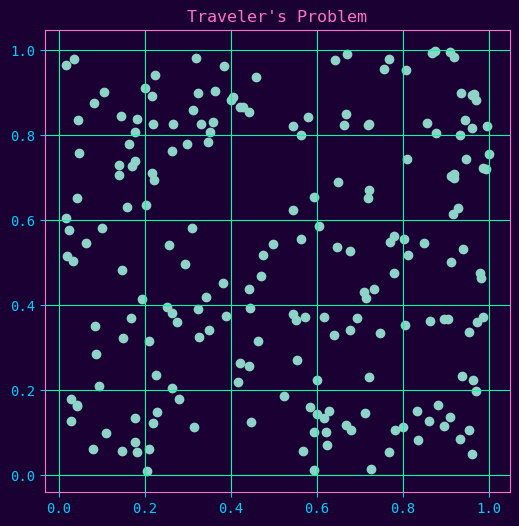

In [10]:
def generate_tsp_problem(number_of_cities: int) -> tuple[list[float], list[float], list[list[float]]]:
    x_coordinates = []
    y_coordinates = []
    distances = []
    for i in range(number_of_cities):
        distances.append([0]*number_of_cities)

    for i in range(number_of_cities):
        x_coordinates.append(rm.random())
        y_coordinates.append(rm.random())

    for i in range(0, number_of_cities):
        for j in range(i, number_of_cities):
            distances[i][j] = np.sqrt(pow(x_coordinates[i]-x_coordinates[j],2) + pow(y_coordinates[i]-y_coordinates[j],2))
            distances[j][i] = distances[i][j]

    return x_coordinates, y_coordinates, distances

def plot_tsp_problem(x_coordinates, y_coordinates, route=None):
    plt.figure(figsize=(6, 6))

    if route is not None:
        xs = [x_coordinates[i] for i in route]
        ys = [y_coordinates[i] for i in route]

        plt.scatter(xs, ys)
        plt.plot(xs, ys, marker='o')  # draw the path

        for k in range(len(route)-1):
            plt.text(xs[k] + 0.01, ys[k] + 0.01, str(k), fontsize=9)

        plt.title("Traveler's Journey")
    else:
        plt.scatter(x_coordinates, y_coordinates)
        plt.title("Traveler's Problem")

    plt.grid(True)
    plt.show()

x_coordinates,y_coordinates,distances = generate_tsp_problem(200)
plot_tsp_problem(x_coordinates,y_coordinates)

def closest_neighbour(distances: list[list[float]])->tuple[float, list[int]]:
    best_route = []
    for initial_city in range(len(distances)):
        total_distance = len(distances) * 12
        current_city = initial_city
        total_distance_try = 0
        exclude = [initial_city]
        for i in range(len(distances)-1):
            excluding_filter = [distances[current_city][j] for j in exclude]
            total_distance_try = total_distance_try + min(x for x in distances[current_city] if x not in excluding_filter)
            current_city = distances[current_city].index(min(x for x in distances[current_city] if x not in excluding_filter))
            exclude.append(current_city)
        total_distance_try = total_distance_try + distances[initial_city][current_city]

        if total_distance > total_distance_try:
            total_distance = total_distance_try
            best_route = exclude + [initial_city]
    return total_distance, best_route

Next we will generate multiple functions to implement each of the previously mentioned perturbation methods:
- Randomize, which arranges the list of cities on a random fashion.

- Swap, which returns the list of cities interchanging to random numbers positions.

- Inverse, which returns the list of cities but inverting one section of the whole array (selects two random positions and inverts the corresponding section of the array).

We will also create a function that sums the total distance between cities of a determined route following the correct order of visited cities and the distance matrix.

In [22]:
def randomize(route: list[int])->list[int]:
    new_route = copy.copy(route)
    rm.shuffle(new_route)
    return new_route

def swap(route: list[int])->list[int]:
    while True:
        first_random_integer = rm.randint(0,len(route)-1)
        second_random_integer = rm.randint(0,len(route)-1)
        if first_random_integer != second_random_integer: break
    new_route = copy.copy(route)
    new_route[first_random_integer] = route[second_random_integer]
    new_route[second_random_integer] = route[first_random_integer]
    return new_route

def inverse(route: list[int])->list[int]:
    new_route = copy.copy(route)
    while True:
        first_random_integer = rm.randint(0,len(route)-1)
        second_random_integer = rm.randint(0,len(route)-1)
        if first_random_integer != second_random_integer and first_random_integer < second_random_integer: break
    new_route[first_random_integer:second_random_integer] = reversed(route[first_random_integer:second_random_integer])
    return new_route

def evaluate_distance(route,distances):
    total_distance = 0
    for i in range(len(route)-1):
        total_distance = total_distance + distances[route[i]][route[i+1]]
    total_distance = total_distance + distances[route[0]][route[-1]]

    return total_distance

Now we will implement the Simulated Annealing algorithm following the provided pseudocode:
```
Input:
    S          ← solución inicial
    C(x)       ← función de coste
    T          ← temperatura inicial
Output:
    S_best     ← solución aproximada óptima
while not frozen(T) do
    while not equilibrium(T) do
        S_new ← perturb(S)
        if C(S_new) < C(S) then
            S ← S_new
        else if accept_worse(C(S_new), C(S), T) then
            S ← S_new
        end if
    end while
    T ← reduce_temperature(T)
end while
return S
```

The following input parameters will be provided:
- Initial temperature
- Alpha (percentual decrease for each iteration)
- Number of thermalization iterations
- Minimum temperature
- Distances matrix
- Route randomization method

In [16]:
def simulated_annealing(
    distances,
    initial_temperature = 10,
    alpha = 0.99,
    number_of_iterations_of_thermalization = 100,
    minimum_temperature = 10**-6,
    aleatorization_method = "inverse",
    route = None
    ):
    total_distance_array = []
    temperature_array = []
    if route == None:
        route=list(range(len(distances[0])))
    temperature = initial_temperature
    while temperature > minimum_temperature:
        total_distance = evaluate_distance(route,distances)
        for _ in range(number_of_iterations_of_thermalization):
            if aleatorization_method == "randomize": new_route = randomize(route)
            elif aleatorization_method == "swap": new_route = swap(route)
            elif aleatorization_method == "inverse": new_route = inverse(route)
            new_total_distance  = evaluate_distance(new_route,distances)
            delta = new_total_distance - total_distance
            if (delta < 0) or (rm.random() < np.exp(-delta/temperature)):
                route, total_distance = new_route, new_total_distance
                total_distance_array.append(total_distance)
                temperature_array.append(temperature)
        temperature = temperature*alpha
    route.append(route[0])

    return total_distance, route, total_distance_array, temperature_array

The following section solves the TSP problem using the Closest Neighbour Algorithm approach:

13.049311456024189
[199, 21, 192, 196, 66, 178, 46, 156, 111, 85, 92, 164, 94, 100, 44, 110, 154, 181, 151, 180, 47, 187, 112, 105, 166, 72, 158, 49, 48, 148, 165, 169, 99, 22, 186, 191, 108, 51, 88, 40, 113, 132, 3, 50, 95, 63, 159, 161, 45, 170, 61, 116, 71, 70, 53, 7, 147, 127, 176, 140, 163, 68, 195, 172, 35, 160, 114, 153, 174, 17, 32, 74, 84, 73, 60, 122, 149, 97, 101, 43, 81, 41, 89, 56, 146, 96, 37, 145, 190, 133, 82, 193, 123, 58, 34, 8, 78, 65, 27, 23, 124, 91, 104, 188, 80, 121, 93, 54, 106, 13, 130, 129, 83, 138, 38, 36, 9, 117, 16, 183, 155, 28, 5, 120, 119, 14, 57, 103, 177, 79, 182, 126, 115, 75, 171, 162, 69, 109, 185, 24, 19, 26, 2, 139, 157, 55, 25, 197, 179, 39, 175, 52, 144, 59, 15, 135, 198, 118, 194, 142, 1, 173, 4, 62, 107, 11, 86, 18, 137, 76, 12, 167, 141, 10, 98, 77, 189, 64, 125, 102, 90, 150, 136, 87, 29, 42, 20, 131, 143, 134, 30, 0, 6, 152, 184, 31, 128, 33, 67, 168, 199]


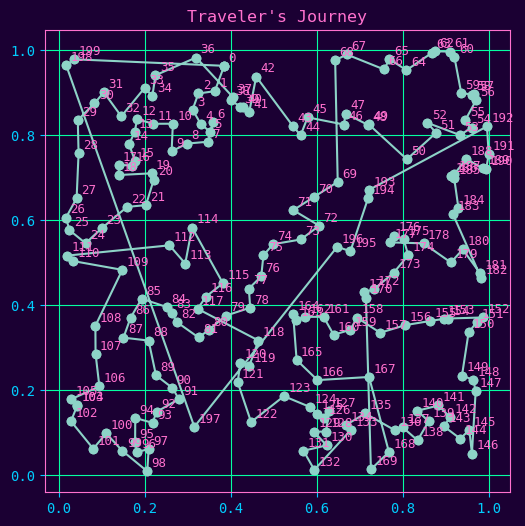

In [13]:
total_distance_closest_neighbour, route_closest_neighbour = closest_neighbour(distances)
print(total_distance_closest_neighbour)
print(route_closest_neighbour)
plot_tsp_problem(x_coordinates, y_coordinates, route_closest_neighbour)

94.6071157071005
[23, 130, 66, 94, 196, 64, 127, 29, 82, 145, 14, 86, 161, 4, 116, 37, 123, 8, 62, 162, 106, 177, 136, 139, 185, 158, 78, 11, 189, 50, 176, 0, 153, 67, 104, 97, 35, 186, 152, 150, 98, 76, 155, 193, 114, 1, 175, 102, 73, 113, 51, 149, 179, 7, 74, 25, 174, 68, 160, 87, 140, 30, 83, 164, 129, 5, 58, 18, 32, 44, 46, 147, 19, 6, 96, 187, 75, 115, 95, 191, 192, 89, 57, 16, 126, 85, 119, 42, 60, 69, 141, 90, 47, 77, 117, 80, 131, 53, 41, 27, 194, 120, 49, 36, 178, 34, 33, 166, 133, 48, 111, 124, 132, 159, 91, 181, 100, 137, 183, 128, 122, 163, 63, 110, 61, 12, 103, 21, 59, 20, 180, 156, 167, 26, 10, 22, 172, 101, 148, 190, 169, 3, 99, 72, 182, 39, 199, 52, 107, 55, 56, 144, 151, 170, 198, 138, 13, 28, 84, 168, 93, 188, 121, 125, 109, 157, 2, 195, 43, 135, 134, 105, 173, 154, 15, 24, 171, 65, 81, 45, 92, 70, 71, 112, 88, 40, 38, 108, 146, 184, 118, 79, 31, 143, 197, 17, 142, 9, 54, 165, 23]


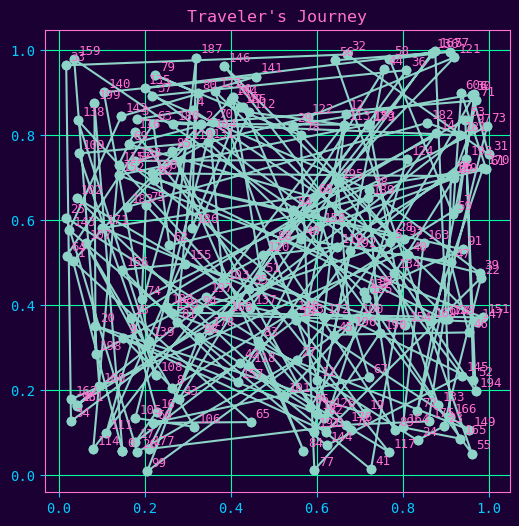

In [18]:
total_distance_randomize, route_randomize, total_distance_array_randomize, temperature_array_randomize = simulated_annealing(distances, aleatorization_method = "randomize")
print(total_distance_randomize)
print(route_randomize)
plot_tsp_problem(x_coordinates, y_coordinates, route_randomize)

20.032416032069538
[25, 55, 2, 139, 24, 109, 19, 26, 197, 30, 134, 143, 116, 71, 170, 3, 21, 196, 92, 110, 154, 85, 111, 66, 46, 174, 153, 114, 160, 195, 172, 35, 161, 63, 132, 113, 50, 95, 32, 84, 31, 128, 73, 149, 97, 101, 62, 1, 194, 142, 57, 79, 14, 119, 86, 120, 5, 28, 43, 9, 117, 56, 89, 146, 37, 96, 13, 112, 151, 181, 168, 67, 148, 48, 49, 166, 105, 83, 138, 38, 187, 47, 180, 44, 100, 99, 165, 169, 94, 186, 22, 191, 192, 184, 125, 90, 150, 102, 189, 17, 178, 156, 190, 145, 54, 93, 124, 78, 27, 65, 58, 33, 193, 82, 133, 188, 80, 121, 104, 91, 23, 8, 34, 123, 41, 81, 36, 61, 131, 42, 29, 87, 136, 144, 52, 175, 179, 39, 59, 15, 135, 198, 141, 12, 167, 74, 88, 51, 40, 159, 45, 152, 64, 118, 18, 162, 171, 103, 11, 183, 155, 16, 4, 173, 0, 6, 147, 127, 163, 68, 140, 176, 7, 53, 70, 20, 77, 98, 10, 69, 75, 115, 126, 106, 130, 129, 72, 158, 164, 108, 199, 60, 122, 107, 177, 182, 76, 137, 185, 157, 25]


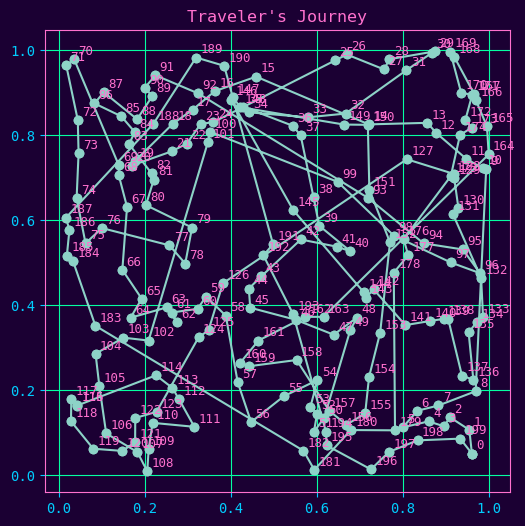

In [24]:
total_distance_swap, route_swap, total_distance_array_swap, temperature_array_swap = simulated_annealing(distances, aleatorization_method = "swap")
print(total_distance_swap)
print(route_swap)
plot_tsp_problem(x_coordinates, y_coordinates, route_swap)

11.503372596332133
[3, 63, 159, 45, 170, 161, 174, 153, 114, 160, 35, 172, 195, 68, 163, 140, 176, 127, 147, 7, 53, 6, 0, 30, 134, 143, 70, 116, 71, 61, 131, 20, 42, 29, 87, 90, 125, 77, 189, 64, 98, 10, 31, 128, 84, 73, 149, 97, 122, 60, 74, 32, 184, 152, 17, 95, 50, 132, 113, 40, 51, 88, 46, 66, 178, 156, 111, 85, 180, 47, 38, 83, 138, 117, 9, 36, 101, 107, 62, 4, 173, 1, 142, 118, 194, 12, 167, 141, 198, 135, 15, 59, 102, 150, 136, 144, 52, 175, 39, 179, 197, 55, 25, 157, 139, 2, 26, 19, 24, 185, 137, 76, 69, 109, 18, 162, 75, 171, 177, 182, 115, 126, 79, 57, 103, 14, 119, 120, 86, 11, 28, 155, 183, 16, 43, 81, 41, 82, 193, 5, 33, 65, 27, 78, 8, 23, 124, 91, 104, 188, 80, 121, 93, 34, 58, 123, 133, 190, 89, 56, 146, 37, 145, 54, 106, 96, 13, 105, 166, 130, 129, 72, 158, 49, 112, 187, 110, 154, 151, 181, 48, 148, 165, 67, 168, 169, 22, 191, 186, 94, 99, 44, 100, 164, 92, 196, 192, 21, 108, 199, 3]


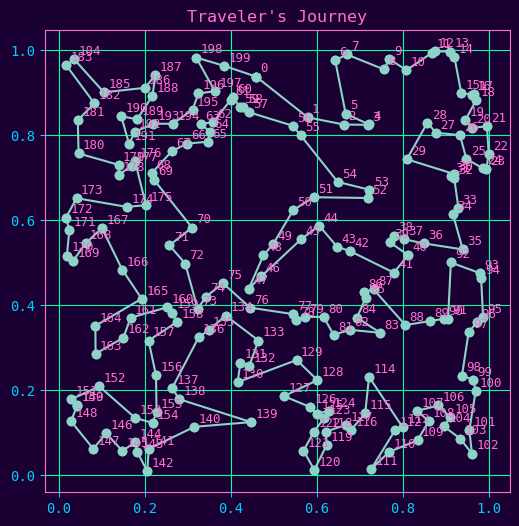

In [25]:
total_distance_inverse, route_inverse, total_distance_array_inverse, temperature_array_inverse = simulated_annealing(distances, aleatorization_method = "inverse")
print(total_distance_inverse)
print(route_inverse)
plot_tsp_problem(x_coordinates, y_coordinates, route_inverse)

The following observations can be made from the previous table:

- The most effective method for solving the problem is undoubtedly **Simulated Annealing** using the **Inverse** operator. It achieves very good TSP solutions for all evaluated numbers of cities while requiring very little computation time. This will be the reference method against which the other approaches are compared.

- The second most effective method is the **Closest Neighbour Algorithm**, which obtains route distances only slightly larger than those achieved by the previous method and generally does so faster (except when the number of cities increases significantly, since for 200 cities it takes more than three times as long as the Inverse method).

- The third most effective method is **Simulated Annealing** using the **Swap** operator. It produces results slightly faster than the Inverse approach but significantly worse in terms of the total distance traveled. In particular, the deterioration in performance is much greater between this method and the Closest Neighbour approach than between the two best-performing methods, with the total route length approaching twice the optimal value obtained by the Inverse method.

- Finally, by a considerable margin, the worst-performing method is **Randomize**, which does not represent a suitable candidate for solving the TSP under any of the evaluated conditions.

To compare the convergence between the different Simulated Annealing aleatorization methods two graphs will be plotted, one one the evolution of the total traveled distance when solving the problem and other containing the evolution of the temperature, both compared against the number of iterations.

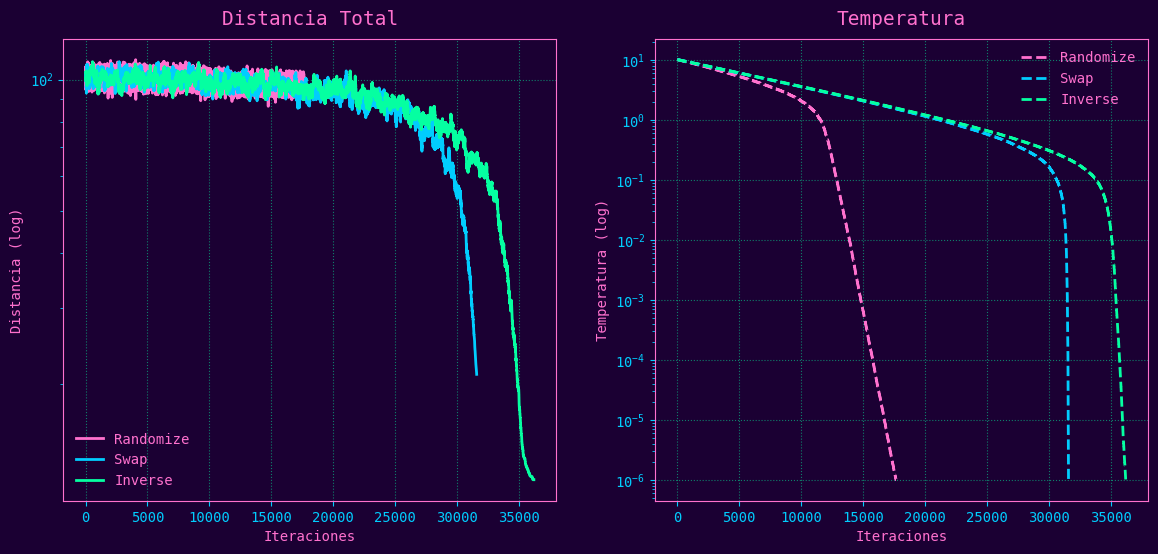

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Distancia
axs[0].plot(total_distance_array_randomize, color="#ff71ce", linewidth=2, label="Randomize")
axs[0].plot(total_distance_array_swap, color="#01cdfe", linewidth=2, label="Swap")
axs[0].plot(total_distance_array_inverse, color="#05ffa1", linewidth=2, label="Inverse")

axs[0].set_yscale("log")
axs[0].set_title("Distancia Total", fontsize=14, pad=10)
axs[0].set_xlabel("Iteraciones")
axs[0].set_ylabel("Distancia (log)")
axs[0].grid(True, linestyle=":", alpha=0.5)
axs[0].legend(frameon=False)

# Temperatura
axs[1].plot(temperature_array_randomize, color="#ff71ce", linestyle="--", linewidth=2, label="Randomize")
axs[1].plot(temperature_array_swap, color="#01cdfe", linestyle="--", linewidth=2, label="Swap")
axs[1].plot(temperature_array_inverse, color="#05ffa1", linestyle="--", linewidth=2, label="Inverse")

axs[1].set_yscale("log")
axs[1].set_title("Temperatura", fontsize=14, pad=10)
axs[1].set_xlabel("Iteraciones")
axs[1].set_ylabel("Temperatura (log)")
axs[1].grid(True, linestyle=":", alpha=0.5)
axs[1].legend(frameon=False)

plt.show()

From these graphs, a number of conclusions can be drawn regarding the general behavior of the Simulated Annealing algorithm:

* The algorithm starts with high route distances and improves gradually in a slow and noisy manner, which indicates a proper exploration phase.
* Towards the end of the execution, a sharp decrease in route distance can be observed, coinciding with very low temperatures, which marks the exploitation phase.
* This behavior is consistent with what is expected from Simulated Annealing and confirms that the algorithm has been implemented correctly.

When examining the different operators used in each case:

* **Randomize**:

  * Converges more quickly.
  * Exhibits more aggressive cooling.
  * Produces lower-quality final solutions.

* **Swap**:

  * Exploration shows lower deviation from the mean.
  * Convergence occurs later.
  * Produces intermediate-quality results when compared with the other two operators.

* **Inverse**:

  * Produces the best final solutions (shortest route distances).
  * Achieves a more stable and structured improvement process, with fewer fluctuations around the mean during exploration.
  * Preserves important local relationships within the route.
  * Is the most suitable operator for this problem.

By examining the temperature graph, the following conclusions can be drawn:

* **Randomize** exhibits rapid cooling, which explains its early convergence.
* **Swap** and **Inverse** maintain higher temperatures for a longer period, promoting broader exploration of the search space.
* Significant improvements in route distance occur when the temperature falls below low threshold values.

Therefore, the final conclusions regarding this algorithm are:

* The algorithm functions correctly and exhibits a clear transition from exploration to exploitation.
* Operator ranking:

  1. **Inverse**
  2. **Swap**
  3. **Randomize**
* The most effective configuration is **Inverse combined with a slow cooling schedule**.